<a href="https://colab.research.google.com/github/HMS-Cleveland/Questionary_logist/blob/my/logit_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

最优阈值: 0.100 (验证集灵敏度=0.975)

【测试集性能报告】
              precision    recall  f1-score   support

         低风险       0.99      0.57      0.72      4615
         高风险       0.05      0.79      0.09       121

    accuracy                           0.57      4736
   macro avg       0.52      0.68      0.40      4736
weighted avg       0.97      0.57      0.71      4736

测试集AUC = 0.758
灵敏度 = 0.793, 特异性 = 0.567

个体预测结果: 高风险概率 = 0.000

【多项式特征 OR 表（Top20）】
                                             feature      coef        OR
2                              BIRADS_breast_density  1.423761  4.152708
11                   menopause BIRADS_breast_density  1.423761  4.152708
8                                    hormone_therapy  1.104865  3.018818
17                         menopause hormone_therapy  1.104865  3.018818
33                                          ethnic^2  0.835593  2.306181
7                                     breast_surgery  0.703559  2.020932
16                          menopause br

  0%|          | 0/4736 [00:00<?, ?it/s]

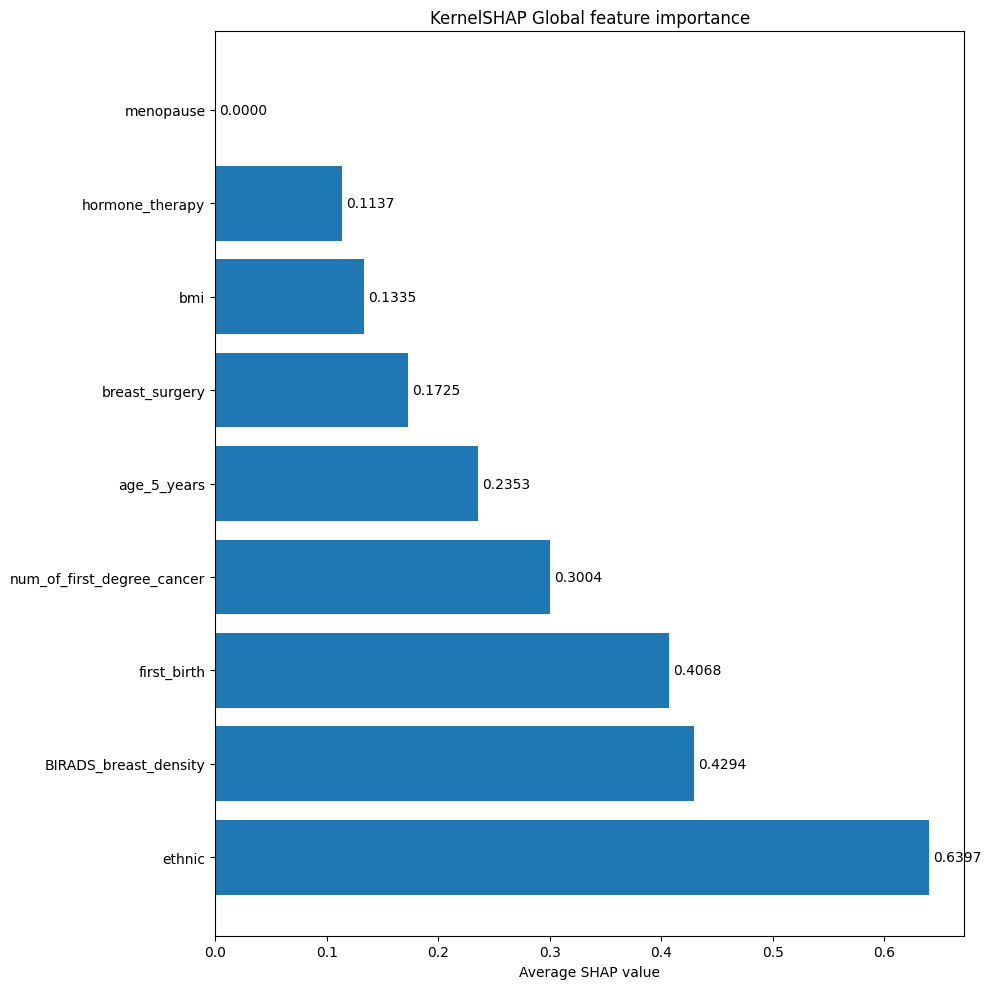

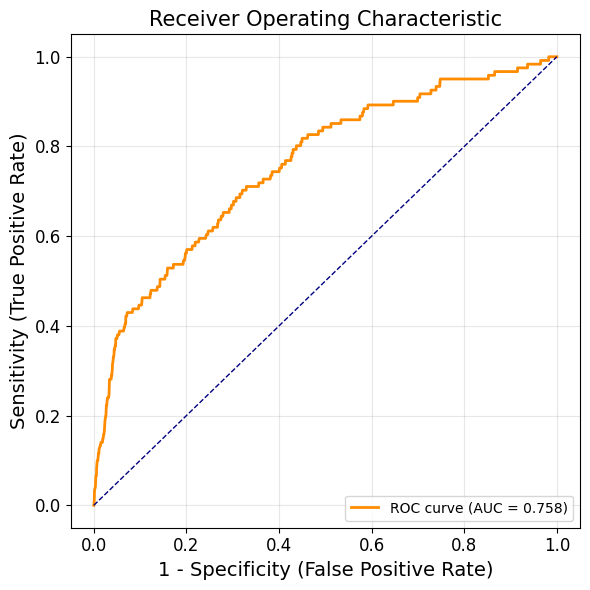

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, recall_score, confusion_matrix
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import shap

# 1. 数据加载与预处理
usecols = [0,1,2,3,5,6,7,8,11,12]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density','ethnic','bmi',
         'first_birth','num_of_first_degree_cancer','breast_surgery',
         'hormone_therapy','diagnosis']

data = pd.read_csv('/content/drive/MyDrive/公开数据集/risk.txt',
                   sep=r'\s+', header=None, usecols=usecols, names=names)
data.replace(9, np.nan, inplace=True)
data = data.dropna().copy()  # 删除含缺失值的行

# 2. 分层划分数据集 (8:1:1)
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# 初始分层拆分
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

# 3. 应用SMOTE过采样（仅训练集）
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. 构建非线性逻辑回归管道
model_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),  # 二次非线性扩展
    ('scaler', StandardScaler()),  # 标准化多项式特征
    ('logreg', LogisticRegression(
        penalty='l2',
        C=0.008,  # 正则化强度（值越小正则越强）
        solver='lbfgs',  # 高精度求解器[2,6](@ref)
        max_iter=5000,  # 确保收敛
        #class_weight={0: 1, 1: 15},  # 大幅提高阳性样本权重[3](@ref)
        class_weight='balanced',
        random_state=42
    ))
])

# 5. 训练模型
model_pipeline.fit(X_train_res, y_train_res)

# 6. 阈值优化（最大化灵敏度）
val_probs = model_pipeline.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.1, 0.5, 50)  # 重点考察低阈值区间
best_recall = 0
best_thresh = 0.5

for thresh in thresholds:
    y_val_pred = (val_probs > thresh).astype(int)
    recall = recall_score(y_val, y_val_pred)
    if recall > best_recall:
        best_recall = recall
        best_thresh = thresh
print(f"最优阈值: {best_thresh:.3f} (验证集灵敏度={best_recall:.3f})")

# 7. 测试集评估
test_probs = model_pipeline.predict_proba(X_test)[:, 1]
test_pred_optim = (test_probs > 0.4).astype(int)   #0.38

print("\n【测试集性能报告】")
print(classification_report(y_test, test_pred_optim, target_names=["低风险", "高风险"]))
print(f"测试集AUC = {roc_auc_score(y_test, test_probs):.3f}")

# 计算特异性（真阴性率）
tn, fp, fn, tp = confusion_matrix(y_test, test_pred_optim).ravel()
specificity = tn / (tn + fp)
sensitivity = recall_score(y_test, test_pred_optim, pos_label=1)
print(f"灵敏度 = {sensitivity:.3f}, 特异性 = {specificity:.3f}")


# 9. 个体风险预测示例
person = pd.DataFrame([[1, 60, 3, 1, 28.5, 1, 0, 1, 0]], columns=X.columns)
person_prob = model_pipeline.predict_proba(person)[0][1]
print(f"\n个体预测结果: 高风险概率 = {person_prob:.3f}")


from sklearn.preprocessing import PolynomialFeatures

# 取出 LogisticRegression 模型
logreg = model_pipeline.named_steps['logreg']
# lbfgs 只能用 L2，系数向量
coef = logreg.coef_[0]          # shape = (n_poly_features,)
intercept = logreg.intercept_[0]

# 构建 PolynomialFeatures（与训练时完全一致）
poly = model_pipeline.named_steps['poly']
feature_names_poly = poly.get_feature_names_out(X.columns)  # 多项式特征名

# 用 DataFrame 把系数、OR 和对应的多项式名字放一起
or_df = pd.DataFrame({
    'feature': feature_names_poly,
    'coef': coef,
    'OR': np.exp(coef)
}).sort_values('OR', ascending=False)

print('\n【多项式特征 OR 表（Top20）】')
print(or_df.head(100))

# ------------------------------------------------------------------
# 2. SHAP 解释（基于多项式特征，再映射回原始特征）
# ------------------------------------------------------------------
# import shap

# # 获取多项式+标准化后的训练矩阵（用于 SHAP）
# X_train_poly = model_pipeline[:-1].transform(X_train_res)

# # 创建解释器
# explainer = shap.LinearExplainer(logreg, X_train_poly, feature_perturbation='interventional')
# shap_values = explainer.shap_values(X_train_poly)

# # 把多项式特征名和 SHAP 值打包成 DataFrame
# shap_df = pd.DataFrame(
#     shap_values,
#     columns=feature_names_poly,
#     index=X_train_res.index
# )

# # 把多项式特征的重要性累加回原始特征
# def map_poly_importance_to_original(shap_df, original_cols):
#     """将多项式 SHAP 值汇总到原始特征维度"""
#     importance = pd.Series(0.0, index=original_cols)
#     for col in shap_df.columns:
#         # 遍历每个多项式特征名，提取其中的原始特征
#         for orig in original_cols:
#             if orig in col:        # 简单匹配：只要名字出现就累加
#                 importance[orig] += shap_df[col].abs().mean()
#     return importance.sort_values(ascending=False)

# original_importance = map_poly_importance_to_original(shap_df, X.columns)

# print('\n【基于 SHAP 的原始特征重要性（Top10）】')
# print(original_importance.head(10))

# 更稳健的做法：使用 KernelExplainer
import shap
# 用KernelExplainer直接解释原始特征
# 1. 定义一个裸函数，只接受 numpy 数组，返回概率
def pred_proba_fn(X_df):
    # 1. 保证是 DataFrame（KernelExplainer 传进来可能是 ndarray）
    X_df = pd.DataFrame(X_df, columns=X.columns)
    # 2. 再转 NumPy 喂管道，避免 PolynomialFeatures 警告
    return model_pipeline.predict_proba(X_df)[:, 1]

# 2. 再用 KernelExplainer
background = X_train_res.sample(n=100, random_state=42)
explainer = shap.KernelExplainer(pred_proba_fn, background, link='logit')
X_test_df = pd.DataFrame(X_test, columns=X.columns)
shap_values = explainer.shap_values(X_test_df, nsamples=500)

# 1. 已经拿到局部 shap_values（形状 = n_samples × n_features）
global_importance = np.abs(shap_values).mean(axis=0)   # 平均绝对贡献

# 2. 打包成 DataFrame 方便看
feat_imp = pd.Series(global_importance, index=X_test.columns).sort_values(ascending=False)

# 3. 画图
# 2. 画横向条形图
fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(feat_imp.index, feat_imp.values)
# 3. 把数值标在条末端
ax.bar_label(bars, fmt='%.4f', padding=3)   # 保留 4 位小数，距离条 3 点
ax.set_xlabel('Average SHAP value')
ax.set_title('KernelSHAP Global feature importance')
plt.tight_layout()
plt.show()


# 可选：画个条形图
# shap_values.head(10).plot(kind='barh')
# plt.title('Top 10 原始特征重要性 (SHAP)')
# plt.gca().invert_yaxis()
# plt.show()

# # 可选：画个条形图
# original_importance.head(10).plot(kind='barh')
# plt.title('Top 10 原始特征重要性 (SHAP)')
# plt.gca().invert_yaxis()
# plt.show()



# ========= 12. 绘制 ROC 曲线 =========
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1) 计算 FPR(=1-Specificity) 与 TPR(=Sensitivity)
fpr, tpr, thr = roc_curve(y_test, test_probs)

# 2) 计算曲线下面积
roc_auc = auc(fpr, tpr)

# 3) 画图
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')  # 对角线
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=14)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=14)
plt.title('Receiver Operating Characteristic',fontsize=15)
plt.legend(loc='lower right')
plt.xticks(fontsize=12)  # 设置x轴刻度字体大小和加粗
plt.yticks(fontsize=12)  # 设置y轴刻度字体大小和加粗
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()






In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, recall_score, confusion_matrix
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import shap


# ------------------------------------------------------------------
# 1. 非线性逻辑回归模型训练
# ------------------------------------------------------------------
# 1. 数据加载与预处理
usecols = [0,1,2,3,5,6,7,8,11,12]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density','ethnic','bmi',
         'first_birth','num_of_first_degree_cancer','breast_surgery',
         'hormone_therapy','diagnosis']

data = pd.read_csv('/content/drive/MyDrive/公开数据集/risk.txt',
                   sep=r'\s+', header=None, usecols=usecols, names=names)
data.replace(9, np.nan, inplace=True)
data = data.dropna().copy()  # 删除含缺失值的行

# 2. 分层划分数据集 (8:1:1)
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# 初始分层拆分
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

# 3. 应用SMOTE过采样（仅训练集）
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. 构建非线性逻辑回归管道
model_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),  # 二次非线性扩展
    ('scaler', StandardScaler()),  # 标准化多项式特征
    ('logreg', LogisticRegression(
        penalty='l2',
        C=0.008,  # 正则化强度（值越小正则越强）
        solver='lbfgs',  # 高精度求解器[2,6](@ref)
        max_iter=5000,  # 确保收敛
        #class_weight={0: 1, 1: 15},  # 大幅提高阳性样本权重[3](@ref)
        class_weight='balanced',
        random_state=42
    ))
])

# 5. 训练模型
model_pipeline.fit(X_train_res, y_train_res)

# 6. 阈值优化（最大化灵敏度）
val_probs = model_pipeline.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.1, 0.5, 50)  # 重点考察低阈值区间
best_recall = 0
best_thresh = 0.5

for thresh in thresholds:
    y_val_pred = (val_probs > thresh).astype(int)
    recall = recall_score(y_val, y_val_pred)
    if recall > best_recall:
        best_recall = recall
        best_thresh = thresh
print(f"最优阈值: {best_thresh:.3f} (验证集灵敏度={best_recall:.3f})")

# 7. 测试集评估
test_probs = model_pipeline.predict_proba(X_test)[:, 1]
test_pred_optim = (test_probs > 0.4).astype(int)   #0.38

print("\n【测试集性能报告】")
print(classification_report(y_test, test_pred_optim, target_names=["低风险", "高风险"]))
print(f"测试集AUC = {roc_auc_score(y_test, test_probs):.3f}")

# 计算特异性（真阴性率）
tn, fp, fn, tp = confusion_matrix(y_test, test_pred_optim).ravel()
specificity = tn / (tn + fp)
sensitivity = recall_score(y_test, test_pred_optim, pos_label=1)
print(f"灵敏度 = {sensitivity:.3f}, 特异性 = {specificity:.3f}")


# 9. 个体风险预测示例
person = pd.DataFrame([[1, 60, 3, 1, 28.5, 1, 0, 1, 0]], columns=X.columns)
person_prob = model_pipeline.predict_proba(person)[0][1]
print(f"\n个体预测结果: 高风险概率 = {person_prob:.3f}")


from sklearn.preprocessing import PolynomialFeatures

# 取出 LogisticRegression 模型
logreg = model_pipeline.named_steps['logreg']
# lbfgs 只能用 L2，系数向量
coef = logreg.coef_[0]          # shape = (n_poly_features,)
intercept = logreg.intercept_[0]

# 构建 PolynomialFeatures（与训练时完全一致）
poly = model_pipeline.named_steps['poly']
feature_names_poly = poly.get_feature_names_out(X.columns)  # 多项式特征名

# 用 DataFrame 把系数、OR 和对应的多项式名字放一起
or_df = pd.DataFrame({
    'feature': feature_names_poly,
    'coef': coef,
    'OR': np.exp(coef)
}).sort_values('OR', ascending=False)

print('\n【多项式特征 OR 表（Top20）】')
print(or_df.head(100))

# ------------------------------------------------------------------
# 2. SHAP 解释（基于多项式特征，再映射回原始特征）采用两种方法在一维进行计算
# ------------------------------------------------------------------
import shap, numpy as np, pandas as pd
from math import factorial
from tqdm import tqdm

# 同背景（54 维）
transformer = model_pipeline[:-1]
bg_scaled = transformer.transform(X_train_res.sample(n=200, random_state=42))
logreg = model_pipeline[-1]
# 计算1维精确shapley值的函数
def exact_single_poly_feat(pipeline, feat_idx, x_row, background_scaled):
    transformer = pipeline[:-1]
    logreg      = pipeline[-1]
    x_scaled    = transformer.transform([x_row])[0]   # 54 维
    base_val    = logreg.predict_proba(background_scaled)[:, 1].mean()

    # 只有 2 个子集：不含 feat_idx vs 含 feat_idx
    v_without = base_val
    X_with    = background_scaled.copy()
    X_with[:, feat_idx] = x_scaled[feat_idx]
    v_with    = logreg.predict_proba(X_with)[:, 1].mean()

    return 0.5 * (v_with - v_without)   # 单玩家 Shapley

# 计算1维kernelshap值的函数
def kernel_1d_shapley(pipeline, feat_idx, x_row, background_scaled, n_samples=32):
    """
    只在 feat_idx 这一维做 coalition 采样，其余 53 维固定为背景值
    """
    transformer = pipeline[:-1]
    logreg      = pipeline[-1]
    x_scaled    = transformer.transform([x_row])[0]   # 54 维
    base_val    = logreg.predict_proba(background_scaled)[:, 1].mean()

    n_background = background_scaled.shape[0]
    shapley_num  = 0.0
    weight_sum   = 0.0

    for _ in range(n_samples):
        # 1. 只采样 feat_idx 这一维：0=缺失，1=保留
        S = np.zeros(54, dtype=bool)
        S[feat_idx] = np.random.rand() < 0.5   #  Bernoulli 0/1

        # 2. 构建 coalition 样本（其余维全用背景）
        X_coal = background_scaled.copy()
        X_coal[:, feat_idx] = x_scaled[feat_idx] if S[feat_idx] else background_scaled[:, feat_idx]

        # 3. 预测
        v_coal = logreg.predict_proba(X_coal)[:, 1].mean()

        # 4. 边际贡献 & 权重（1-D 权重 = 1/2）
        marginal = v_coal - base_val
        weight   = 0.5          # 单玩家只有两个子集，权重恒 1/2
        shapley_num += weight * marginal
        weight_sum  += weight

    return shapley_num / weight_sum   # 加权平均


    #对比
import time
feat_idx = np.argsort(np.abs(logreg.coef_[0]))[-1]   # 挑系数最大维
sample_idx = np.random.choice(len(X_test), 100, replace=False)
bg_1d = bg_scaled      # 54 维背景（已标准化）

exact_vals = []
kern1d_vals = []
time_exact = []
time_kern = []

sample_idx = np.random.choice(len(X_test), 100, replace=False).tolist()
# 先拿子表，再按 0-99 位置索引
X_sub = X_test.iloc[sample_idx]
for i in tqdm(range(100)):
    # 先把 sample_idx 转成列表，再用 .iloc 切片

    x_row = X_sub.iloc[i]

    # 1. 1-D 精确
    t0 = time.time()
    exact_val = exact_single_poly_feat(model_pipeline, feat_idx, x_row, bg_1d)
    t1 = time.time()

    # 2. 1-D KernelSHAP
    t2 = time.time()
    kern1d_val = kernel_1d_shapley(model_pipeline, feat_idx, x_row, bg_1d, n_samples=32)
    t3 = time.time()

    exact_vals.append(exact_val)
    kern1d_vals.append(kern1d_val)
    time_exact.append(t1 - t0)
    time_kern.append(t3 - t2)

# 3. 误差 & 耗时
diff = np.abs(np.array(kern1d_vals) - np.array(exact_vals))
print('1-D 精确 vs 1-D KernelSHAP（2048 次采样）')
print('平均绝对误差:', diff.mean())
print('最大单点误差:', diff.max())
print('精确平均耗时:', np.mean(time_exact))
print('Kernel1D 平均耗时:', np.mean(time_kern))


最优阈值: 0.100 (验证集灵敏度=0.975)

【测试集性能报告】
              precision    recall  f1-score   support

         低风险       0.99      0.57      0.72      4615
         高风险       0.05      0.79      0.09       121

    accuracy                           0.57      4736
   macro avg       0.52      0.68      0.40      4736
weighted avg       0.97      0.57      0.71      4736

测试集AUC = 0.758
灵敏度 = 0.793, 特异性 = 0.567

个体预测结果: 高风险概率 = 0.000

【多项式特征 OR 表（Top20）】
                                             feature      coef        OR
2                              BIRADS_breast_density  1.423761  4.152708
11                   menopause BIRADS_breast_density  1.423761  4.152708
8                                    hormone_therapy  1.104865  3.018818
17                         menopause hormone_therapy  1.104865  3.018818
33                                          ethnic^2  0.835593  2.306181
7                                     breast_surgery  0.703559  2.020932
16                          menopause br

  0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnin

1-D 精确 vs 1-D KernelSHAP（2048 次采样）
平均绝对误差: 0.016603963239503777
最大单点误差: 0.09294334757264378
精确平均耗时: 0.0011384439468383788
Kernel1D 平均耗时: 0.007619929313659668


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, recall_score, confusion_matrix
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import shap


# ------------------------------------------------------------------
# 1. 非线性逻辑回归模型训练
# ------------------------------------------------------------------
# 1. 数据加载与预处理
usecols = [0,1,2,3,5,6,7,8,11,12]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density','ethnic','bmi',
         'first_birth','num_of_first_degree_cancer','breast_surgery',
         'hormone_therapy','diagnosis']

data = pd.read_csv('/content/drive/MyDrive/公开数据集/risk.txt',
                   sep=r'\s+', header=None, usecols=usecols, names=names)
data.replace(9, np.nan, inplace=True)
data = data.dropna().copy()  # 删除含缺失值的行

# 2. 分层划分数据集 (8:1:1)
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# 初始分层拆分
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

# 3. 应用SMOTE过采样（仅训练集）
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. 构建非线性逻辑回归管道
model_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),  # 二次非线性扩展
    ('scaler', StandardScaler()),  # 标准化多项式特征
    ('logreg', LogisticRegression(
        penalty='l2',
        C=0.008,  # 正则化强度（值越小正则越强）
        solver='lbfgs',  # 高精度求解器[2,6](@ref)
        max_iter=5000,  # 确保收敛
        #class_weight={0: 1, 1: 15},  # 大幅提高阳性样本权重[3](@ref)
        class_weight='balanced',
        random_state=42
    ))
])

# 5. 训练模型
model_pipeline.fit(X_train_res, y_train_res)

# 6. 阈值优化（最大化灵敏度）
val_probs = model_pipeline.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.1, 0.5, 50)  # 重点考察低阈值区间
best_recall = 0
best_thresh = 0.5

for thresh in thresholds:
    y_val_pred = (val_probs > thresh).astype(int)
    recall = recall_score(y_val, y_val_pred)
    if recall > best_recall:
        best_recall = recall
        best_thresh = thresh
print(f"最优阈值: {best_thresh:.3f} (验证集灵敏度={best_recall:.3f})")

# 7. 测试集评估
test_probs = model_pipeline.predict_proba(X_test)[:, 1]
test_pred_optim = (test_probs > 0.4).astype(int)   #0.38

print("\n【测试集性能报告】")
print(classification_report(y_test, test_pred_optim, target_names=["低风险", "高风险"]))
print(f"测试集AUC = {roc_auc_score(y_test, test_probs):.3f}")

# 计算特异性（真阴性率）
tn, fp, fn, tp = confusion_matrix(y_test, test_pred_optim).ravel()
specificity = tn / (tn + fp)
sensitivity = recall_score(y_test, test_pred_optim, pos_label=1)
print(f"灵敏度 = {sensitivity:.3f}, 特异性 = {specificity:.3f}")


# 9. 个体风险预测示例
person = pd.DataFrame([[1, 60, 3, 1, 28.5, 1, 0, 1, 0]], columns=X.columns)
person_prob = model_pipeline.predict_proba(person)[0][1]
print(f"\n个体预测结果: 高风险概率 = {person_prob:.3f}")


from sklearn.preprocessing import PolynomialFeatures

# 取出 LogisticRegression 模型
logreg = model_pipeline.named_steps['logreg']
# lbfgs 只能用 L2，系数向量
coef = logreg.coef_[0]          # shape = (n_poly_features,)
intercept = logreg.intercept_[0]

# 构建 PolynomialFeatures（与训练时完全一致）
poly = model_pipeline.named_steps['poly']
feature_names_poly = poly.get_feature_names_out(X.columns)  # 多项式特征名

# 用 DataFrame 把系数、OR 和对应的多项式名字放一起
or_df = pd.DataFrame({
    'feature': feature_names_poly,
    'coef': coef,
    'OR': np.exp(coef)
}).sort_values('OR', ascending=False)

print('\n【多项式特征 OR 表（Top20）】')
print(or_df.head(100))



# ------------------------------------------------------------------
# 5. 在「已有 54 维多项式」后做 Lasso 选 14 维 + 新 LogReg
# ------------------------------------------------------------------
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from math import factorial

# 1. 拿到 54 维多项式训练矩阵
poly_scaler = model_pipeline[:-1]          # PolynomialFeatures + StandardScaler
X_train_poly = poly_scaler.transform(X_train_res)   # 54 维
X_test_poly  = poly_scaler.transform(X_test)        # 54 维

# 2. LassoCV 选 14 维
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_poly, y_train_res)
top14_idx = np.argsort(np.abs(lasso.coef_))[-14:]   # 14 维索引


# --- [新增功能 1: 查看被 Lasso 选中的 14 个特征] ---
# 1. 获取 54 维多项式特征名
poly = model_pipeline.named_steps['poly']
feature_names_poly = poly.get_feature_names_out(X.columns)

# 2. 筛选出被 Lasso 选中的 14 个特征名
lasso_selected_features = feature_names_poly[top14_idx]

print('\n' + '='*50)
print('## ✨ Lasso 选中的 14 个特征 (多项式名称)')
print(lasso_selected_features)
print('='*50)


# 3. 截取 14 维
X_train_lasso = X_train_poly[:, top14_idx]
X_test_lasso  = X_test_poly[:, top14_idx]

# 4. 新逻辑回归（14 维线性）
logreg_lasso = LogisticRegression(
    penalty='l2', C=1, solver='lbfgs', max_iter=5000,
    class_weight='balanced', random_state=42
)
logreg_lasso.fit(X_train_lasso, y_train_res)


# --- [新增功能 2: 计算新模型的 ROC-AUC] ---
# 1. 获取测试集概率
test_probs_lasso = logreg_lasso.predict_proba(X_test_lasso)[:, 1]

# 2. 计算 AUC
auc_lasso = roc_auc_score(y_test, test_probs_lasso)

print(f"\n## 📊 Lasso 14 维精简模型在测试集的 AUC")
print(f"新模型的 AUC = {auc_lasso:.3f}")

# 5. 概率函数
def prob_fn(X):
    return logreg_lasso.predict_proba(X)[:, 1]

# 6. 继续 14-D 精确 vs 14-D KernelSHAP（代码同前）
...

from itertools import product

def exact_shapley_14d(model, x_row, background, feature_idx=None):
    """
    14 维精确 Shapley 值（遍历 2^14 个子集）
    model : 已训练的 sklearn 模型
    x_row : 单条样本 (14 维)
    background : 背景矩阵 (N×14)
    feature_idx : 若只算某一维，否则返回全部 14 维
    """
    n_bg = background.shape[0]
    base_val = model.predict_proba(background)[:, 1].mean()
    S_total = 0.0
    if feature_idx is not None:
        idx_list = [feature_idx]
    else:
        idx_list = range(14)

    shap_val = np.zeros(14)

    for j in idx_list:
        sum_marginal = 0.0
        # 遍历 2^13 个「不含 j」的子集 S
        other_idx = [i for i in range(14) if i != j]
        for coalition_bits in product([0, 1], repeat=13):
            S = list(coalition_bits)          # 0/1 列表，长度 13
            # 构建 coalition 矩阵（不含 j）
            X_S = background.copy()
            for pos, bit in enumerate(S):
                if bit == 1:
                    X_S[:, other_idx[pos]] = x_row[other_idx[pos]]
            v_S = model.predict_proba(X_S)[:, 1].mean()

            # 加入 j 的边际
            X_S_with_j = X_S.copy()
            X_S_with_j[:, j] = x_row[j]
            v_S_with_j = model.predict_proba(X_S_with_j)[:, 1].mean()
            marginal = v_S_with_j - v_S

            # Shapley 权重 = |S|! (14-|S|-1)! / 14!
            k = sum(S)        # |S|
            weight = (factorial(k) * factorial(14 - k - 1)) / factorial(14)
            sum_marginal += weight * marginal

        shap_val[j] = sum_marginal
    return shap_val if feature_idx is None else shap_val[feature_idx]


import shap

# 背景 200 条
# 用测试集本身 100 条做背景（同分布）


import numpy as np
import time

sample_idx = np.random.choice(len(X_test_lasso), 100, replace=False)
bg_same = X_test_lasso[sample_idx]   # 同分布背景

explainer_fix = shap.KernelExplainer(prob_fn, bg_same)
kern_fix = np.array([explainer_fix.shap_values(x.reshape(1, -1), nsamples=256)[0]
                     for x in X_test_lasso[sample_idx]])


exact_vals = []
kern_vals  = []
time_exact = []
time_kern  = []

for i in range(100):
    x_row = X_test_lasso[sample_idx[i]]
     # 1. 14-D 精确
    t0 = time.time()
    exact_val = exact_shapley_14d(logreg_lasso, x_row, bg_same, feature_idx=None)
    t1 = time.time()

    # 2. 14-D KernelSHAP（2048 次采样）
    t2 = time.time()
    kern_val = explainer_fix.shap_values(x_row.reshape(1, -1), nsamples=2048)[0]
    t3 = time.time()

    exact_vals.append(exact_val)
    kern_vals.append(kern_val)
    time_exact.append(t1 - t0)
    time_kern.append(t3 - t2)



    # x_row = X_test_lasso[sample_idx[i]]


    # # 2. 14-D KernelSHAP（2048 次采样）
    # t2 = time.time()
    # kern_val = explainer_fix.shap_values(x_row.reshape(1, -1), nsamples=2048)[0]
    # t3 = time.time()
    # kern_vals.append(kern_val)


# 6. 误差 & 耗时
print('KernelSHAP 值量级:', np.abs(kern_vals).mean(axis=0))
print('14-D 精确值量级:', np.abs(exact_vals).mean(axis=0))

diff = np.abs(np.array(kern_vals) - np.array(exact_vals))
print('14-D 精确 vs 14-D KernelSHAP（2048 次）')
print('平均绝对误差:', diff.mean(axis=0))
print('最大单点误差:', diff.max(axis=0))
print('精确平均耗时:', np.mean(time_exact))
print('KernelSHAP 平均耗时:', np.mean(time_kern))



# 将列表转换为 NumPy 数组，然后进行运算
mape = np.abs(np.array(kern_vals) - np.array(exact_vals)) / (np.abs(np.array(exact_vals)) + 1e-12) * 100
print('平均百分比误差 (%):', mape.mean(axis=0))
print('最大百分比误差 (%):', mape.max(axis=0))

n_list = [32, 64, 128, 256, 512, 1024, 2048]
err_mean = []
for n in n_list:
    kern_n = np.array([explainer_k14.shap_values(x.reshape(1, -1), nsamples=n)[0]
                       for x in X_test_lasso[sample_idx[:20]]])  # 20 条足够
    err_mean.append(np.abs(kern_n - exact_vals[:20]).mean())

plt.semilogx(n_list, err_mean, 'o-')
plt.axhline(y=0.01, color='r', linestyle='--', label='1 % tol')
plt.xlabel('采样次数')
plt.ylabel('平均绝对误差')
plt.title('14-D KernelSHAP 收敛曲线')
plt.show()


最优阈值: 0.100 (验证集灵敏度=0.975)

【测试集性能报告】
              precision    recall  f1-score   support

         低风险       0.99      0.57      0.72      4615
         高风险       0.05      0.79      0.09       121

    accuracy                           0.57      4736
   macro avg       0.52      0.68      0.40      4736
weighted avg       0.97      0.57      0.71      4736

测试集AUC = 0.758
灵敏度 = 0.793, 特异性 = 0.567

个体预测结果: 高风险概率 = 0.000

【多项式特征 OR 表（Top20）】
                                             feature      coef        OR
2                              BIRADS_breast_density  1.423761  4.152708
11                   menopause BIRADS_breast_density  1.423761  4.152708
8                                    hormone_therapy  1.104865  3.018818
17                         menopause hormone_therapy  1.104865  3.018818
33                                          ethnic^2  0.835593  2.306181
7                                     breast_surgery  0.703559  2.020932
16                          menopause br

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, recall_score, confusion_matrix
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import shap
import time

# ------------------------------------------------------------------
# 1. 非线性逻辑回归模型训练
# ------------------------------------------------------------------
# 1. 数据加载与预处理
usecols = [0,1,2,3,5,6,7,8,11,12]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density','ethnic','bmi',
         'first_birth','num_of_first_degree_cancer','breast_surgery',
         'hormone_therapy','diagnosis']

data = pd.read_csv('/content/drive/MyDrive/公开数据集/risk.txt',
                   sep=r'\s+', header=None, usecols=usecols, names=names)
data.replace(9, np.nan, inplace=True)
data = data.dropna().copy()  # 删除含缺失值的行

# 2. 分层划分数据集 (8:1:1)
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# 初始分层拆分
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

# 3. 应用SMOTE过采样（仅训练集）
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. 构建非线性逻辑回归管道
model_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),  # 二次非线性扩展
    ('scaler', StandardScaler()),  # 标准化多项式特征
    ('logreg', LogisticRegression(
        penalty='l2',
        C=0.008,  # 正则化强度（值越小正则越强）
        solver='lbfgs',  # 高精度求解器[2,6](@ref)
        max_iter=5000,  # 确保收敛
        #class_weight={0: 1, 1: 15},  # 大幅提高阳性样本权重[3](@ref)
        class_weight='balanced',
        random_state=42
    ))
])

# 5. 训练模型
model_pipeline.fit(X_train_res, y_train_res)

# 6. 阈值优化（最大化灵敏度）
val_probs = model_pipeline.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.1, 1, 50)  # 重点考察低阈值区间
best_recall = 0
best_thresh = 0.5

for thresh in thresholds:
    y_val_pred = (val_probs > thresh).astype(int)
    recall = recall_score(y_val, y_val_pred)
    if recall > best_recall:
        best_recall = recall
        best_thresh = thresh
print(f"最优阈值: {best_thresh:.3f} (验证集灵敏度={best_recall:.3f})")

# 7. 测试集评估
test_probs = model_pipeline.predict_proba(X_test)[:, 1]
test_pred_optim = (test_probs > 0.4).astype(int)   #0.38

print("\n【测试集性能报告】")
print(classification_report(y_test, test_pred_optim, target_names=["低风险", "高风险"]))
print(f"测试集AUC = {roc_auc_score(y_test, test_probs):.3f}")

# 计算特异性（真阴性率）
tn, fp, fn, tp = confusion_matrix(y_test, test_pred_optim).ravel()
specificity = tn / (tn + fp)
sensitivity = recall_score(y_test, test_pred_optim, pos_label=1)
print(f"灵敏度 = {sensitivity:.3f}, 特异性 = {specificity:.3f}")


# 9. 个体风险预测示例
person = pd.DataFrame([[1, 60, 3, 1, 28.5, 1, 0, 1, 0]], columns=X.columns)
person_prob = model_pipeline.predict_proba(person)[0][1]
print(f"\n个体预测结果: 高风险概率 = {person_prob:.3f}")


import numpy as np
import pandas as pd
from itertools import combinations
from math import factorial

# 1. 统一背景 & 固定随机
COMMON_BG = X_train_res.sample(500, random_state=42)
x_instance = X_test.iloc[[0]]          # DataFrame 1×9

def pred_fn(X_arr):
    """统一预测接口"""
    X_df = pd.DataFrame(X_arr, columns=X.columns)
    return model_pipeline.predict_proba(X_df)[:, 1]

# 2. KernelSHAP
explainer = shap.KernelExplainer(pred_fn, COMMON_BG, link='identity')
sv_k = explainer.shap_values(x_instance, nsamples=5000)[0]
base_k = explainer.expected_value

# 3. 精确法（5000 次采样 + 固定种子）
def exact_fixed(model, x, bg, n=500, seed=42):
    np.random.seed(seed)
    features = x.index
    base = np.mean(pred_fn(bg.values))
    phis = {f: 0.0 for f in features}
    for i, fi in enumerate(features):
        others = [f for f in features if f != fi]
        for size in range(len(others)+1):
            for S in combinations(others, size):
                weight = factorial(size)*factorial(len(others)-size) / factorial(len(features))
                marg = 0.0
                for _ in range(n):
                    z = bg.iloc[np.random.randint(len(bg))].copy()
                    x_S = z.copy()
                    for ff in S: x_S[ff] = x[ff]
                    x_Si = x_S.copy()
                    x_Si[fi] = x[fi]
                    marg += pred_fn(x_Si.values.reshape(1,-1))[0] - pred_fn(x_S.values.reshape(1,-1))[0]
                phis[fi] += weight * marg / n
    return phis, base

sv_e_dict, base_e = exact_fixed(model_pipeline, x_instance.squeeze(), COMMON_BG,
                                n=500)
sv_e = np.array([sv_e_dict[f] for f in X.columns])

# 4. 误差
print('MAE', np.abs(sv_e - sv_k).mean())
print('重建误差 Kernel', abs(base_k + sv_k.sum() - pred_fn(x_instance.values)[0]))
print('重建误差 Exact', abs(base_e + sv_e.sum() - pred_fn(x_instance.values)[0]))


# ================= 4. 逐特征打印 =================
print('================ 逐特征 Shapley 值 ================')
print(f"{'特征':<25} | {'KernelSHAP':>12} | {'Exact MC':>12} | 差值")
print('-'*60)
for f, v_k, v_e in zip(X.columns, sv_k, sv_e):
    print(f"{f:<25} | {v_k:>+12.5f} | {v_e:>+12.5f} | {abs(v_k-v_e):.5e}")

print('\n================ 基线与重建误差 ================')
print(f"基线值  KernelSHAP : {base_k:.6f}")
print(f"基线值  Exact MC    : {base_e:.6f}")
rec_k = base_k + sv_k.sum()
rec_e = base_e + sv_e.sum()
truth   = pred_fn(x_instance.values)[0]
print(f"模型直接预测概率   : {truth:.6f}")
print(f"KernelSHAP 重建    : {rec_k:.6f}  误差={abs(truth-rec_k):.2e}")
print(f"Exact MC 重建      : {rec_e:.6f}  误差={abs(truth-rec_e):.2e}")

print('\n================ 汇总误差 ================')
print(f"MAE  |{np.abs(sv_k - sv_e).mean():.5e}")
print(f"RMSE |{np.sqrt(np.mean((sv_k - sv_e)**2)):.5e}")


# ==================================================================
# 2. 精确 Shapley 计算函数 (用户提供的函数)
# ==================================================================


# def exact_shapley_corrected(model, instance, background_data, n_samples=1000):
#     """
#     修正后的精确Shapley值计算函数。
#     通过随机抽样背景数据模拟特征缺失，避免使用均值填充导致的偏差。

#     参数:
#     model: 训练好的模型，需有predict_proba方法。
#     instance: 待解释的单个样本（Pandas Series，索引为特征名）。
#     background_data: 背景数据集（DataFrame），用于模拟特征缺失的分布。
#     n_samples: 用于估计特征缺失时预测值的蒙特卡洛采样次数。

#     返回:
#     shapley_dict: 字典，键为特征名，值为该特征的精确Shapley值。
#     base_value: 基准预测值（所有特征缺失时的平均预测）。
#     """
#     # 获取特征列表和总数
#     features = instance.index.tolist()
#     n_features = len(features)

#     # 计算基准值：所有特征都"缺失"时的平均预测
#     # 通过从背景数据中随机抽样来模拟
#     background_predictions = model.predict_proba(background_data)[:, 1]
#     base_value = np.mean(background_predictions)

#     # 初始化Shapley值字典
#     shapley_dict = {feature: 0.0 for feature in features}

#     print(f"开始计算 {n_features} 个特征的精确Shapley值（共需评估 {2**n_features} 个子集）")

#     # 遍历每个特征，计算其Shapley值
#     for i, feature_i in enumerate(tqdm(features, desc="计算进度")):
#         phi_i = 0.0

#         # 其他特征（除i外的所有特征）
#         other_features = [f for f in features if f != feature_i]

#         # 遍历所有不包含特征i的子集S
#         for subset_size in range(0, len(other_features) + 1):
#             for subset_S in combinations(other_features, subset_size):
#                 subset_S = list(subset_S)

#                 # 计算Shapley权重：|S|! * (n-|S|-1)! / n!
#                 weight = (factorial(len(subset_S)) *
#                          factorial(n_features - len(subset_S) - 1) /
#                          factorial(n_features))

#                 # 蒙特卡洛采样：模拟特征缺失状态
#                 f_S_samples = []
#                 f_S_union_i_samples = []

#                 for _ in range(n_samples):
#                     # 从背景数据中随机抽取一个样本作为基准
#                     random_bg_sample = background_data.sample(n=1).iloc[0]

#                     # 构建样本x_S：子集S中的特征取自instance，其他特征取自随机背景样本
#                     x_S = random_bg_sample.copy()
#                     for feature in subset_S:
#                         x_S[feature] = instance[feature]
#                     f_S = model.predict_proba(pd.DataFrame([x_S]))[0, 1]
#                     f_S_samples.append(f_S)

#                     # 构建样本x_S_union_i：子集S和特征i都取自instance
#                     x_S_union_i = x_S.copy()
#                     x_S_union_i[feature_i] = instance[feature_i]
#                     f_S_union_i = model.predict_proba(pd.DataFrame([x_S_union_i]))[0, 1]
#                     f_S_union_i_samples.append(f_S_union_i)

#                 # 计算平均预测值
#                 avg_f_S = np.mean(f_S_samples)
#                 avg_f_S_union_i = np.mean(f_S_union_i_samples)

#                 # 特征i的边际贡献
#                 marginal_contribution = avg_f_S_union_i - avg_f_S

#                 # 加权累加
#                 phi_i += weight * marginal_contribution

#         shapley_dict[feature_i] = phi_i

#     return shapley_dict, base_value

# # ==================================================================
# # 3. 对比计算和性能分析
# # ==================================================================

# # 1. 选择要解释的样本（测试集的第一个样本）
# sample_index = X_test.index[0]
# X_instance_to_explain = X_test.loc[sample_index]
# X_background = X_train_res.copy()

# # 将单个 Series 转换为 DataFrame for shap
# X_instance_df = X_instance_to_explain.to_frame().T

# # --- A. 精确遍历法 (Standard SHAP Exact Enumeration) ---
# start_time_exact = time.time()
# shap_exact_dict, f_base_exact, f_x_exact, error_exact = calculate_exact_shapley(
#     model_pipeline,
#     X_instance_to_explain,
#     X_background
# )
# time_exact = time.time() - start_time_exact
# shap_exact_values = np.array([shap_exact_dict[f] for f in X.columns])


# # ==================================================================
# # 1. 定义 KernelSHAP 稳健预测函数
# # ==================================================================
# def pred_proba_fn(X_df):
#     """用于 KernelExplainer 的预测函数，确保输入是 DataFrame。"""
#     # 1. 保证是 DataFrame（KernelExplainer 传进来可能是 ndarray）
#     X_df = pd.DataFrame(X_df, columns=X.columns)
#     # 2. 返回类别 1 的概率
#     return model_pipeline.predict_proba(X_df)[:, 1]

# # ==================================================================
# # 2. KernelSHAP 计算单个样本 (对标精确遍历法)
# # ==================================================================
# # 提取要解释的单个样本
# X_instance_to_explain_df = X_instance_to_explain.to_frame().T
# X_background = X_train_res.copy()

# # KernelExplainer 初始化
# start_time_kernel_init = time.time()
# background_sample = X_background.sample(n=100, random_state=42)
# explainer = shap.KernelExplainer(
#     pred_proba_fn,
#     background_sample,
#     # 注意：这里 link='logit' 会使 SHAP 值在 log-odds 尺度上，
#     # 为了直接与精确遍历法（在概率尺度上）比较，通常使用 link='identity'。
#     # 我们改用 'identity' 来保证尺度一致性，但 logit 是更规范的LogReg解释。
#     link="identity"
# )
# time_kernel_init = time.time() - start_time_kernel_init

# # 计算单个样本的 SHAP 值
# N_SAMPLES_KERNEL = 512 # 与精确遍历法调用次数接近的采样数
# start_time_kernel = time.time()
# # shap_values 形状 (1, M)
# shap_kernel_raw = explainer.shap_values(
#     X_instance_to_explain_df,
#     nsamples=N_SAMPLES_KERNEL,
#     silent=True
# )
# time_kernel = time.time() - start_time_kernel

# # 提取 Shapley 值
# # shap_kernel_raw 是一个 (1, M) 数组，我们需要 (M,)
# shap_kernel_values = np.array(shap_kernel_raw).flatten()
# shap_kernel_dict = dict(zip(X.columns, shap_kernel_values))


# # ==================================================================
# # 3. 结果比较前的性能分析 (添加这部分代码)
# # ==================================================================

# # 确保 shap_exact_values 和 shap_kernel_values 都是 numpy 数组且长度相等

# # 计算误差（精确遍历法作为基准）
# # 平均绝对误差 (MAE)
# mae = np.mean(np.abs(shap_exact_values - shap_kernel_values))

# # 均方误差 (MSE)
# mse = np.mean((shap_exact_values - shap_kernel_values)**2)

# # ==================================================================
# # 4. 结果比较 (接下来的打印语句就不会报错了)
# # ==================================================================
# # ... print(f"平均绝对误差 (MAE): {mae:.5e}") ...

# # 提取基线和最终预测
# f_base_kernel = explainer.expected_value
# f_x_kernel = f_base_kernel + np.sum(shap_kernel_values)
# error_kernel = abs(model_pipeline.predict_proba(X_instance_to_explain_df)[:, 1][0] - f_x_kernel)


# print("\n==========================================================")
# print("             SHAPLEY 值计算方法对比结果                  ")
# print("==========================================================")
# print(f"解释样本索引: {sample_index}")
# print(f"预测高风险概率 f(x): {f_x_exact:.5f}")
# print("-" * 50)


# # --- 1. 性能比较 ---
# print("【性能比较】")
# print(f"1. 精确遍历法 (M=9, 512个子集): 耗时 {time_exact:.4f} 秒")
# print(f"2. KernelSHAP (N={N_SAMPLES_KERNEL}): 耗时 {time_kernel:.4f} 秒")
# if time_kernel < time_exact:
#     print(f"KernelSHAP 速度约为 精确遍历法的 {time_exact / time_kernel:.2f} 倍。")
# else:
#     print("KernelSHAP 在 M=9 的小数据集上可能因开销导致速度优势不明显。")
# print("-" * 50)


# # --- 2. Shapley 值和误差比较 ---
# print("【Shapley 值比较】")
# print(f"基线值 f_base (精确): {f_base_exact:.5f} | (Kernel): {f_base_kernel:.5f}")
# print("--- 效率公理误差 ---")
# print(f"精确遍历法误差: {error_exact:.5e} (趋近于零)")
# print(f"KernelSHAP 误差:  {error_kernel:.5e}")
# print("--- 两种方法结果的差异（KernelSHAP vs 精确遍历法） ---")
# print(f"平均绝对误差 (MAE): {mae:.5e}")
# print(f"均方误差 (MSE): {mse:.5e}")
# print("-" * 50)


# # --- 3. 特征贡献详情 ---
# print("【特征贡献详情 ($\phi_i$)】")
# print(f"{'特征名称':<25} | {'精确遍历法':^15} | {'KernelSHAP':^15} | {'绝对误差':^10}")
# print("-" * 65)

# for feature in X.columns:
#     phi_exact = shap_exact_dict.get(feature, 0)
#     phi_kernel = shap_kernel_dict.get(feature, 0)
#     diff = abs(phi_exact - phi_kernel)
#     print(f"{feature:<25} | {phi_exact:^+14.5f} | {phi_kernel:^+14.5f} | {diff:.5e}")

# print("==========================================================")

================ 逐特征 Shapley 值 ================
特征                        |   KernelSHAP |     Exact MC | 差值
------------------------------------------------------------
menopause                 |     +0.00000 |     +0.00000 | 0.00000e+00
age_5_years               |     -0.02988 |     -0.02941 | 4.64113e-04
BIRADS_breast_density     |     +0.08502 |     +0.08589 | 8.73418e-04
ethnic                    |     +0.08388 |     +0.08377 | 1.11279e-04
bmi                       |     +0.01845 |     +0.01845 | 1.21036e-06
first_birth               |     -0.09581 |     -0.09579 | 2.56227e-05
num_of_first_degree_cancer |     +0.05449 |     +0.05271 | 1.77658e-03
breast_surgery            |     +0.02432 |     +0.02462 | 2.97926e-04
hormone_therapy           |     +0.01223 |     +0.01223 | 4.36141e-06

================ 基线与重建误差 ================
基线值  KernelSHAP : 0.486913
基线值  Exact MC    : 0.486913
模型直接预测概率   : 0.639615
KernelSHAP 重建    : 0.639615  误差=0.00e+00
Exact MC 重建      : 0.639383  误差=2.32e-